Image dimensions (179x282) are less than 500x500. Resizing...


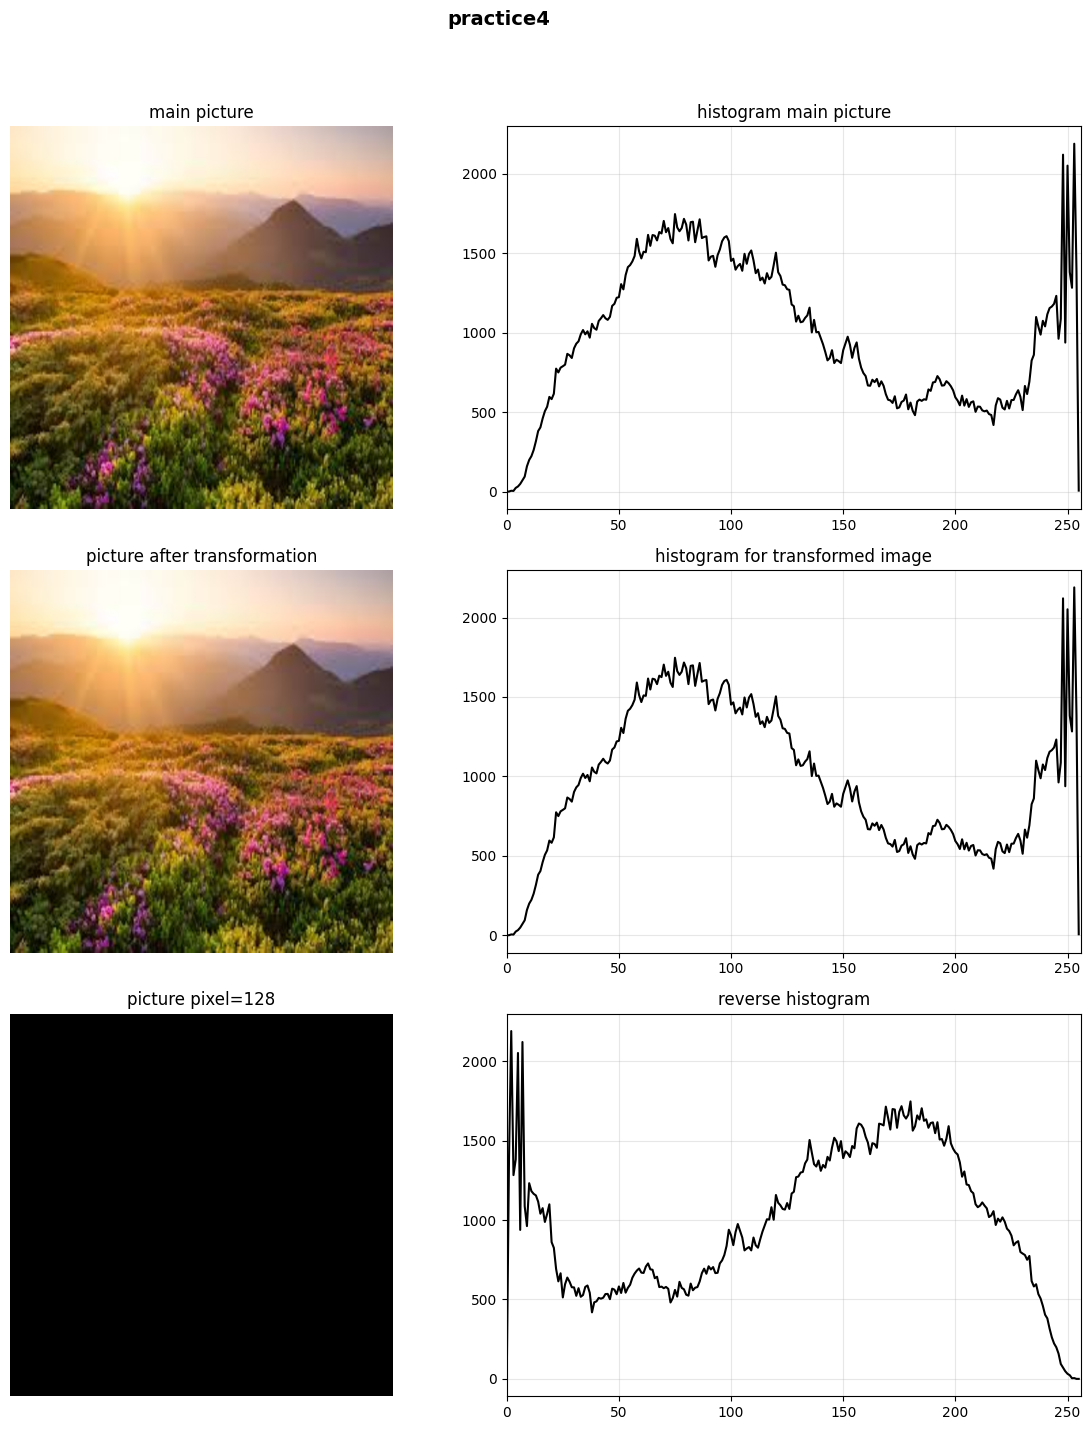

(array([[[199, 231, 254],
        [199, 231, 254],
        [199, 231, 254],
        ...,
        [162, 159, 174],
        [162, 159, 174],
        [162, 159, 174]],

       [[199, 231, 254],
        [199, 231, 254],
        [199, 231, 254],
        ...,
        [162, 159, 174],
        [162, 159, 174],
        [162, 159, 174]],

       [[199, 231, 254],
        [199, 231, 254],
        [199, 231, 254],
        ...,
        [162, 159, 174],
        [162, 159, 174],
        [162, 159, 174]],

       ...,

       [[  4,  11,   8],
        [  3,  12,   9],
        [  2,  14,  10],
        ...,
        [ 12,  72,  81],
        [ 23,  86,  93],
        [ 30,  94, 100]],

       [[  0,   6,   3],
        [  1,  10,   7],
        [  3,  16,  12],
        ...,
        [ 13,  72,  81],
        [ 13,  75,  81],
        [ 13,  77,  82]],

       [[  0,   6,   3],
        [  1,  10,   6],
        [  3,  16,  12],
        ...,
        [ 13,  72,  81],
        [ 11,  74,  80],
        [ 11,  75,  80]

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def image(image_path):
     
    img = cv2.imread(image_path)
  
    h, w = img.shape[:2]
    if h < 500 or w < 500:
        print(f"Image dimensions ({h}x{w}) are less than 500x500. Resizing...")
        img = cv2.resize(img, (max(500, w), max(500, h)))

  
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    histogram_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])


    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15)) 
    fig.suptitle('practice4', fontsize=14, fontweight='bold')


    axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('main picture')
    axes[0, 0].axis('off')

   
    axes[0, 1].plot(histogram_gray, color='black')
    axes[0, 1].set_title('histogram main picture')
    axes[0, 1].set_xlim([0, 256])
    axes[0, 1].grid(True, alpha=0.3)


    img_transformed = img.copy()
    white_pixels = (img_transformed[:, :, 0] == 255) & \
                   (img_transformed[:, :, 1] == 255) & \
                   (img_transformed[:, :, 2] == 255)
    black_pixels = (img_transformed[:, :, 0] == 0) & \
                   (img_transformed[:, :, 1] == 0) & \
                   (img_transformed[:, :, 2] == 0)

    img_transformed[white_pixels] = [0, 0, 0]
    img_transformed[black_pixels] = [255, 255, 255]

    gray_transformed = cv2.cvtColor(img_transformed, cv2.COLOR_BGR2GRAY)
    histogram_transformed = cv2.calcHist([gray_transformed], [0], None, [256], [0, 256])

 
    axes[1, 0].imshow(cv2.cvtColor(img_transformed, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('picture after transformation')
    axes[1, 0].axis('off')


    axes[1, 1].plot(histogram_transformed, color='black')
    axes[1, 1].set_title('histogram for transformed image')
    axes[1, 1].set_xlim([0, 256])
    axes[1, 1].grid(True, alpha=0.3)


    img_uniform = np.full_like(gray, 128, dtype=np.uint8)
    axes[2, 0].imshow(img_uniform, cmap='gray')
    axes[2, 0].set_title('picture pixel=128')
    axes[2, 0].axis('off')

 
    histogram_flipped = histogram_gray[::-1].copy()
    axes[2, 1].plot(histogram_flipped, color='black')
    axes[2, 1].set_title('reverse histogram')
    axes[2, 1].set_xlim([0, 256])
    axes[2, 1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()

    return img, gray, img_transformed
call_fun=image('images.jpg')
print(call_fun)